In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:

assessments = pd.read_csv("ass essments.csv")
courses = pd.read_csv("courses.csv")

# Confirm numeric data types
assessments["score"] = pd.to_numeric(assessments["score"])
assessments["attendance_pct"] = pd.to_numeric(
    assessments["attendance_pct"]
)

# Display d types
print("Score data type:", assessments["score"].dtype)
print("Attendance data type:", assessments["attendance_pct"].dtype)

print("\nAssessment columns:")
print(assessments.dtypes)

Score data type: int64
Attendance data type: int64

Assessment columns:
assessment_id     int64
month               str
course_id           str
batch               str
score             int64
attendance_pct    int64
dtype: object


In [3]:
# Remove exact duplicate rows
assessments = assessments.drop_duplicates()

# Merge assessments with courses using LEFT JOIN
merged = assessments.merge(
    courses,
    on="course_id",
    how="left"
)

# Check number of rows
print("Merged rows:", len(merged))

# Check unmatched course_id records
unmatched = merged["department"].isna().sum()
print("Unmatched course_id records:", unmatched)

# Assertions
assert len(merged) == 12, "Merged DataFrame does not contain exactly 12 rows"
assert unmatched == 0, "Some course_id values were not matched"


Merged rows: 12
Unmatched course_id records: 0


In [4]:
# =================P2=================

# Create pass_flag column
merged["pass_flag"] = (merged["score"] >= 50).astype(int)


print(merged[["score", "pass_flag"]]) 

    score  pass_flag
0      72          1
1      45          0
2      65          1
3      38          0
4      80          1
5      55          1
6      48          0
7      68          1
8      90          1
9      60          1
10     75          1
11     42          0


In [5]:
#  Department-wise summary
department_summary = (
    merged.groupby("department")
    .agg(
        total_assessments=("pass_flag", "count"),
        passing_count=("pass_flag", "sum")
    )
    .reset_index()
)

# Calculate pass rate 
department_summary["pass_rate_%"] = (
    department_summary["passing_count"]
    / department_summary["total_assessments"]
    * 100
)

print("Department-wise Summary:")
print(department_summary)


#  Course-wise summary
course_summary = (
    merged.groupby("course_id")
    .agg(
        total_assessments=("pass_flag", "count"),
        passing_count=("pass_flag", "sum")
    )
    .reset_index()
)

# Calculate pass rate 
course_summary["pass_rate_%"] = (
    course_summary["passing_count"]
    / course_summary["total_assessments"]
    * 100
)

# Find course with lowest pass rate
lowest_course = course_summary.loc[
    course_summary["pass_rate_%"].idxmin()
]

print("\nCourse with Lowest Pass Rate:")
print("Course ID:", lowest_course["course_id"])
print("Passing count (numerator):", lowest_course["passing_count"])
print("Total assessments (denominator):", lowest_course["total_assessments"])
print("Pass rate:", lowest_course["pass_rate_%"])

Department-wise Summary:
   department  total_assessments  passing_count  pass_rate_%
0    Business                  6              5    83.333333
1  Technology                  6              3    50.000000

Course with Lowest Pass Rate:
Course ID: C4
Passing count (numerator): 1
Total assessments (denominator): 3
Pass rate: 33.33333333333333


Monthly Average Score:
month
Jan    55.00
Feb    62.75
Mar    66.75
Name: score, dtype: float64


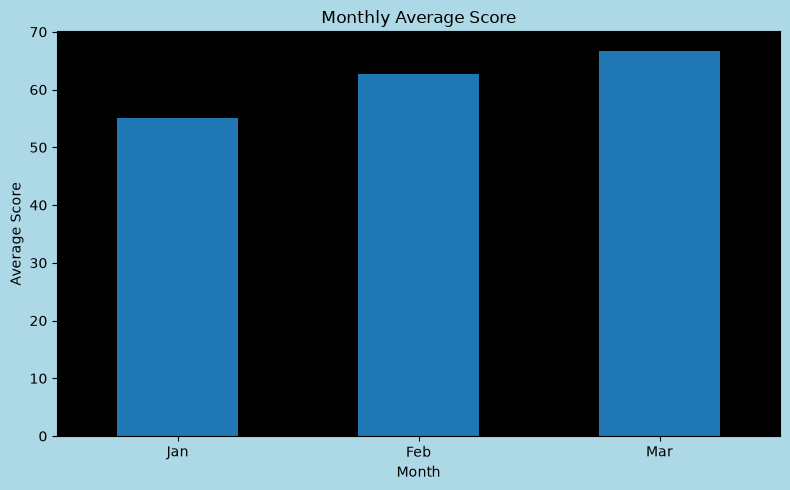

In [14]:
# ================= P3 =================


month_order = ["Jan", "Feb", "Mar"]

# Set month order
merged["month"] = pd.Categorical(
    merged["month"],
    categories=month_order,
    ordered=True
)

# Calculate monthly average score
monthly_avg = (
    merged.groupby("month", observed=False)["score"]
    .mean()
    .reindex(month_order)
)

# Print monthly average
print("Monthly Average Score:")
print(monthly_avg)



plt.figure(figsize=(8, 5), facecolor="lightblue")

ax = monthly_avg.plot(kind="bar")
ax.set_facecolor("black")

plt.title("Monthly Average Score")
plt.xlabel("Month")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.tight_layout()

os.makedirs("outputs", exist_ok=True)

plt.savefig("outputs/python_chart.png", dpi=300)
plt.show()

In [7]:

# Create outputs folder
os.makedirs("outputs", exist_ok=True)

# Export clean merged DataFrame
merged.to_csv(
    "outputs/clean_data.csv",
    index=False
)

# Export department summary
department_summary.to_csv(
    "outputs/python_summary.csv",
    index=False
)

print("Files exported successfully")
print("1. outputs/clean_data.csv")
print("2. outputs/python_summary.csv")

Files exported successfully
1. outputs/clean_data.csv
2. outputs/python_summary.csv
